In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import trim_mean
import math
from pandas.api.types import ( is_numeric_dtype, is_categorical_dtype, is_object_dtype, is_datetime64_any_dtype )
from default_risk.script.variable_profiling import eda_per_table_printing_results
from default_risk.script.variable_profiling import eda_per_table_persisting_result_html
from default_risk.script.variable_profiling import create_files_nulls_per_colmun
import default_risk.config as cfg
import logging
import dtale
import gc



credit_card_df= pd.read_csv(cfg.CREDIT_CARD_BALANCE)

data_frame_size=len(credit_card_df)

credit_card_df.sort_values(["SK_ID_PREV","MONTHS_BALANCE"],inplace=True)


log = logging.getLogger('werkzeug')

with open(cfg.SCHEMA_JSON, "r") as f:
    schema = json.load(f)


#auxiliar functions

def recreate_and_sort_the_serie_given_ids(ids : pd.Series) -> pd.DataFrame :
    recreated_series= credit_card_df[credit_card_df["SK_ID_PREV"].isin(ids)]
    return recreated_series.sort_values(["SK_ID_PREV","MONTHS_BALANCE"])
     

def recreate_and_sort_series_given_rows(rows : pd.DataFrame) -> pd.DataFrame :
    id_rows= rows["SK_ID_PREV"].unique()
    return recreate_and_sort_the_serie_given_ids(id_rows)

def check_invariant(invariant_mask,text_logic_invariant_mask):
    negative_balance= (invariant_mask).sum()
    print(str(negative_balance) + " of cases where " + text_logic_invariant_mask)
    positive_balance_invariant_porcentaje= ((invariant_mask).sum() * 100) / data_frame_size
    print("that represent a " + str(positive_balance_invariant_porcentaje) + "%" + " of cases with violation of this invariant \n")
    
    



Invariants found at the moment: (# number of cell with the proofs and relevant code)

1- If CNT_INSTALMENT_MATURE_CUM > 0 then AMT_INST_MIN_REGULARITY is also !=0. #8

2- Count installment monotonicity: CNT_INSTALMENT_MATURE_CUM is monotonically non-decreasing over time (MONTHS_BALANCE). Starts increasing when AMT_INST_MIN_REGULARITY becomes > 0 and stops when AMT_BALANCE = 0
or in a more formal definition, if Xt-1[CNT_INSTALMENT_MATURE_CUM] > 0 (we are not at the beginning of the time series) and Xt-1[CNT_INSTALMENT_MATURE_CUM] ==Xt[CNT_INSTALMENT_MATURE_CUM] then Xt-1[AMT_BALANCE] == 0  (100%) #8, #9, #10, #11


3- Magnitude Hierarchy: AMT_BALANCE > AMT_RECEIVABLE_PRINCIPAL (100%) #3


4- Gross vs net: AMT_TOTAL_RECEIVABLE >= AMT_RECEIVABLE  (100%) #3




Soft constraints:

3- AMT_TOTAL_RECEIVABLE >= AMT_RECEIVABLE_PRINCIPAL (97,21%) #3
anomalies: Almost always overpayment (AMT_TOTAL_RECEIVABLE < 0) but the capital of the debt was not updated (AMT_RECEIVABLE_PRINCIPAL > 0) the remaining 550 cases with irregular behavior.

4- AMT_BALANCE & AMT_RECEIVABLE_PRINCIPAL > 0 (99.04%) #3
anomalies: Overpayment

5- AMT_DRAWINGS_CURRENT >= (AMT_DRAWINGS_ATM_CURRENT + AMT_DRAWINGS_POS_CURRENT +  AMT_DRAWINGS_OTHER_CURRENT) (99.94%)  #13
anomalies: Data corruption

6- AMT_TOTAL_RECEIVABLE >= AMT_INST_MIN_REGULARITY  (94,2%) #13
anomalies: AMT_TOTAL_RECEIVABLE < 0 in a month with AMT_INST_MIN_REGULARITY defined. The remaining  cases are penalties in the debt. 



Decisions summary: 

1- Compute the difference between  AMT_TOTAL_RECEIVABLE and AMT_BALANCE to keep it as feature and apply Symlog transformation, drop AMT_TOTAL_RECIVABLE and keep AMT_BALANCE as anchor. #4

2- Compute the difference between AMT_PAYMENT_CURRENT and AMT_PAYMENT_TOTAL_CURRENT, keep it as feature and drop AMT_PAYMENT_CURRENT. #5

4- Treat CNT_INSTALMENT_MATURE_CUM missing values as 0. #10

5- Treat AMT_DRAWINGS_POS_CURRENT, AMT_DRAWINGS_OTHER_CURRENT and AMT_DRAWINGS_ATM_CURRENT missing values as 0. #12

6- Clip AMT_BALANCE at 0 (left tail) and extract the negative values as a flag "have_negative_balance". #3 #16

7- Use the first instant where AMT_INST_MIN_REGULARITY changes from 0 as the first month where the payment is expected. #8

8- if AMT_INST_MIN_REGULARITY > AMT_TOTAL_RECEIVABLE (invariant 6 violated) and AMT_TOTAL_RECEIVABLE > 0, compute "inconsistency_gap" as AMT_INST_MIN_REGULARITY -  AMT_TOTAL_RECEIVABLE and apply log1p transform to normalize the scale (heavy outliers) and highly zero-inflated. #15 #16

In [ ]:
#files for the data dictionary
create_files_nulls_per_colmun(credit_card_df,"credit_card_balance")

In [3]:
#run the screening script on credit_card_balance
eda_per_table_printing_results(credit_card_df, schema, "credit_card_balance",False)

--------------------------------------
SK_ID_PREV
basic_data


,cardinality,mode
0,104307,"[1000096, 1000344, 1000455, 1000840, 1000895, ..."


frequency


,CATEGORY,COUNT,SEGMENT
0,1489625,96,top
1,2638662,96,top
2,2761258,96,top
3,2257963,96,top
4,2638478,96,top
5,1531631,96,top
6,2465897,96,top
7,1117052,96,top
8,1284957,96,top
9,2638489,96,top


--------------------------------------
SK_ID_CURR
basic_data


...

,skew,p90,p99,ratio_max_value_p99
0,12.94699,0.0,274.0,11.89781


--------------------------------------
SK_DPD_DEF
basic_data


,min,max,mean,trim_mean,median,standard_deviation,standard_error,coefficient_of_variation
0,0,3260,0.331622,0.0,0.0,21.479231,0.010961,64.770222


distribution_metrics


,skew,p90,p99,ratio_max_value_p99
0,89.830434,0.0,1.0,3260.0


In [ ]:
#3

#In order to compare magnitudes, his semantic meanings and how reliavable are in this dataset we proceed to this validations:


check_invariant((credit_card_df["AMT_RECIVABLE"] > credit_card_df["AMT_TOTAL_RECEIVABLE"]), "AMT_RECIVABLE are bigger than AMT_TOTAL_RECEIVABLE")

check_invariant((credit_card_df["AMT_RECEIVABLE_PRINCIPAL"] > credit_card_df["AMT_TOTAL_RECEIVABLE"]) & ( credit_card_df["CNT_INSTALMENT_MATURE_CUM"] > 1),"AMT_RECEIVABLE_PRINCIPAL are bigger than AMT_TOTAL_RECEIVABLE (once when the payment is ongoing)")

check_invariant(credit_card_df["AMT_RECEIVABLE_PRINCIPAL"] > credit_card_df["AMT_BALANCE"],"AMT_RECEIVABLE_PRINCIPAL is bigger than AMT_BALANCE")

check_invariant((credit_card_df["AMT_BALANCE"] < 0),"AMT_BALANCE is negative")



0 of cases where AMT_RECIVABLE are bigger than AMT_TOTAL_RECEIVABLE
that represent a 0.0% of cases with violation of this invariant 

107270 of cases where AMT_RECEIVABLE_PRINCIPAL are bigger than AMT_TOTAL_RECEIVABLE (once when the payment is ongoing)
that represent a 2.7932626307445854% of cases with violation of this invariant 

0 of cases where AMT_RECEIVABLE_PRINCIPAL is bigger than AMT_BALANCE
that represent a 0.0% of cases with violation of this invariant 

2345 of cases where AMT_BALANCE is negative
that represent a 0.06106274698514079% of cases with violation of this invariant 



In [ ]:
#4
#we identify a high degree of collinearity between AMT_BALANCE and AMT_TOTAL_RECEIVABLE. 
diff = credit_card_df["AMT_BALANCE"] - credit_card_df["AMT_TOTAL_RECEIVABLE"]
non_cero_ammount= (diff != 0).sum()
print("this 2 columns are different in: " + str((non_cero_ammount * 100) / len(diff)) + "% the observations")
diff.describe()
#With 84% of the observations having this 2 columns with equal values but the difference carrying potential signal we decides to:
#1- Drop AMT_TOTAL_RECIVABLE to avoid redundance
#2- Create a feature of the difference
#3- Apply Symlog transformation to the new feature based on the metrics of the .describe() exhibit a distribution dominated by outliers.

In [ ]:
#5
#In the same line, we explore the colineality between "AMT_PAYMENT_CURRENT" & AMT_PAYMENT_TOTAL_CURRENT"
diff = credit_card_df["AMT_PAYMENT_CURRENT"] - credit_card_df["AMT_PAYMENT_TOTAL_CURRENT"]
non_cero_ammount= (diff != 0).sum()
print("this 2 columns are different in: " + str((non_cero_ammount * 100) / len(diff)) + "% the observations")
diff.describe()
#Thes are not redundant but are mathematically linked. Extra_payed_costs = AMT_PAYMENT_TOTAL_CURRENT - AMT_PAYMENT_CURRENT.
#Therefore in order to explicit relationships hard to discover for the model and avoid colineality we will:
#1- Calculate the diference and save in a new column
#2- Drop AMT_PAYMENT_CURRENT because we consider it less reliable and have (19% of missing values) and keep AMT_PAYMENT_TOTAL_CURRENT as anchor (has no missing values)

In [3]:
#6
first_ids_prev_app= (credit_card_df["SK_ID_PREV"].unique())[:1000]
dtale.show(recreate_and_sort_the_serie_given_ids(first_ids_prev_app))                                                                                                                                                                                                                                                                                                    

2026-04-30 15:46:17,914 - ERROR    - Exception on /health [GET]
Traceback (most recent call last):
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 2529, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 1825, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 1821, in full_dispatch_request
    rv = self.preprocess_request()
         ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\default risk\default-risk\Lib\site-packages\flask\app.py", line 2313, in preprocess_request
    rv = self.ensure_sync(before_func)()
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kuroc\OneDrive\Escritorio\defa

2026-04-30 16:47:57,982 - INFO     - Executing shutdown due to inactivity...
2026-04-30 16:48:22,540 - INFO     - Executing shutdown...
2026-04-30 16:48:22,543 - INFO     - Not running with the Werkzeug Server, exiting by searching gc for BaseWSGIServer


In [ ]:
#7
#This proof the existence of rows where the minimun ammout to pay that month to avoid delinquency is missing but exist a debt.
rows_with_null= credit_card_df[credit_card_df["AMT_INST_MIN_REGULARITY"].isna()]
mask_exist_debt= rows_with_null["AMT_BALANCE"].notnull() & rows_with_null["AMT_BALANCE"] != 0
rows_with_null_and_debt= rows_with_null[mask_exist_debt]
dtale.show(recreate_and_sort_series_given_rows(rows_with_null_and_debt))
#this pattern tends to show in the first moment the serie represent a debt, and no necessarily are cases of delinquency.

: 

In [5]:
#8
rows_with_null= credit_card_df[credit_card_df["AMT_INST_MIN_REGULARITY"].isna()]
mask_exist_deb_and_payed_instalments= (rows_with_null["AMT_BALANCE"].notnull()) & (rows_with_null["AMT_BALANCE"] != 0) & (rows_with_null["CNT_INSTALMENT_MATURE_CUM"] > 0)
rows_with_null_and_debt= rows_with_null[mask_exist_deb_and_payed_instalments]
recreate_and_sort_series_given_rows(rows_with_null_and_debt).head()
#this represent that once the client start to repair the debt, always have definied the minimun ammout to avoid delincuency defined 

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF


In [ ]:
#9
#in order to check for the behaivor of nulls and if are legit missing values or corrupted data, we let's continue with "CNT_INSTALMENT_MATURE_CUM".
rows_with_null_values = credit_card_df[credit_card_df["CNT_INSTALMENT_MATURE_CUM"].isna()]
dtale.show(recreate_and_sort_series_given_rows(rows_with_null_values))
#this give us the strong hipotesis that "CNT_INSTALMENT_MATURE_CUM" missing values are "silents ceros".

In [ ]:
#10
#In order to test the hipotesis of "CNT_INSTALMENT_MATURE_CUM" nulls being "silents ceros"
def is_valid_next(series):
    return series.isin([0, 1]) | series.isna()

credit_card_df["NEXT_VALUE_INSTALMENT"] = credit_card_df.groupby("SK_ID_PREV")["CNT_INSTALMENT_MATURE_CUM"].shift(-1)
mask_for_nulls_pattern= (credit_card_df["CNT_INSTALMENT_MATURE_CUM"].isnull()) & ~(is_valid_next(credit_card_df["NEXT_VALUE_INSTALMENT"]))
recreate_and_sort_series_given_rows(credit_card_df[mask_for_nulls_pattern]).head()
#this proof the hipotesis that "CNT_INSTALMENT_MATURE_CUM" missing values are just "silents ceros"


In [ ]:
#11
#We discover a relatioship between "CNT_INSTALMENT_MATURE_CUM" and "AMT_BALANCE", now we want to visualize if there is exception to this.
credit_card_df["CNT_INSTALMENT_IS_CONSTANT_VS_PREV"] = (
    credit_card_df.groupby("SK_ID_PREV")["CNT_INSTALMENT_MATURE_CUM"]
      .diff() == 0
)
rows_without_invariant_fulfiled = credit_card_df[(credit_card_df["CNT_INSTALMENT_IS_CONSTANT_VS_PREV"] == True) & (credit_card_df["AMT_BALANCE"] > 0)]
dtale.show(recreate_and_sort_series_given_rows(rows_without_invariant_fulfiled))
#Seems like the debt is created can have "delay" util start to be paied. But is easy to detect because if we change "AMT_BALANCE" for "AMT_INST_MIN_REGULARITY" > 0 don't exist cases where this condition
#Is true. So the time of the counter of "CNT_INSTALMENT_MATURE_CUM" start to run in the moment where the minimun ammout to don't incurry in delincuency is setted, and stop in the moment "AMT_BALANCE" hits 0.


In [ ]:
#12
#To check if the nulls at AMT_DRAWINGS_ATM_CURRENT, AMT_DRAWINGS_POS_CURRENT and AMT_DRAWINGS_OTHER_CURRENT are just silent ceros we will analize the correlation with AMT_DRAWINGS_CURRENT
check_invariant((credit_card_df["AMT_DRAWINGS_ATM_CURRENT"].isna() & credit_card_df["AMT_DRAWINGS_CURRENT"] > 0), "AMT_DRAWINGS_ATM_CURRENT is null when AMT_DRAWINGS_CURRENT is bigger than 0")

check_invariant((credit_card_df["AMT_DRAWINGS_ATM_CURRENT"].isna() & (credit_card_df["AMT_DRAWINGS_POS_CURRENT"].notna() | credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"])),"the missing values of AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT are not aligned")
#this proof 1- AMT_DRAWINGS_ATM_CURRENT is only null when AMT_DRAWINGS_CURRENT is 0. 2- AMT_DRAWINGS_POS_CURRENT, AMT_DRAWINGS_OTHER_CURRENT and AMT_DRAWINGS_ATM_CURRENT are always null at the same time.
#so the missing values of this 3 columns are actually silents 0.


0 of cases where AMT_DRAWINGS_ATM_CURRENT is null when AMT_DRAWINGS_CURRENT is bigger than 0
that represent a 0.0% of cases with violation of this invariant 

0 of cases where the missing values of AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT are not aligned
that represent a 0.0% of cases with violation of this invariant 



In [ ]:
#13
#We proceed to check if the semantic have consistent representation in magitudes terms in these columns
check_invariant(credit_card_df["AMT_DRAWINGS_ATM_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_ATM_CURRENT are bigger than AMT_DRAWINGS_CURRENT")
check_invariant(credit_card_df["AMT_DRAWINGS_POS_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_POS_CURRENT are bigger than AMT_DRAWINGS_CURRENT")
check_invariant(credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"],"AMT_DRAWINGS_OTHER_CURRENT are bigger than AMT_DRAWINGS_CURRENT")

summatory= (credit_card_df["AMT_DRAWINGS_ATM_CURRENT"]  + credit_card_df["AMT_DRAWINGS_POS_CURRENT"] + credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"])

columns_summed_mask= summatory == credit_card_df["AMT_DRAWINGS_CURRENT"]
check_invariant(~columns_summed_mask,"the sumn of the 3 columns of DRAWINGS don't are equal to the column that holds the total (AMT_DRAWINGS_CURRENT)")


check_invariant(summatory > credit_card_df["AMT_DRAWINGS_CURRENT"], "the sum of the 3 column exceed the total (AMT_DRAWINGS_CURRENT)")


diff= (credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"]  + credit_card_df["AMT_DRAWINGS_POS_CURRENT"] + credit_card_df["AMT_DRAWINGS_OTHER_CURRENT"]) - (credit_card_df["AMT_DRAWINGS_CURRENT"])
diff.describe()

3 of cases where AMT_DRAWINGS_ATM_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

3 of cases where AMT_DRAWINGS_POS_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

3 of cases where AMT_DRAWINGS_OTHER_CURRENT are bigger than AMT_DRAWINGS_CURRENT
that represent a 7.811865285945516e-05% of cases with violation of this invariant 

762121 of cases where the sumn of the 3 columns of DRAWINGS don't are equal to the column that holds the total (AMT_DRAWINGS_CURRENT)
that represent a 19.845288611966943% of cases with violation of this invariant 

2569 of cases where the sum of the 3 column exceed the total (AMT_DRAWINGS_CURRENT)
that represent a 0.06689560639864678% of cases with violation of this invariant 



count    3.090496e+06
mean    -5.691732e+03
std      2.936523e+04
min     -2.287098e+06
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.529847e+06
dtype: float64

In [ ]:
#14
credit_card_df[credit_card_df["AMT_DRAWINGS_ATM_CURRENT"] > credit_card_df["AMT_DRAWINGS_CURRENT"]].head(10)
credit_card_df[credit_card_df["AMT_DRAWINGS_CURRENT"]  < 0].head()
#The invariant don't are violated for negative values on AMT_DRAWINGS_CURRENT. But we don't have enough cases to modelate this, so we have to discard it clipping in 0 the negative side of the scale.

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
438776,2321147,198229,-64,0.0,112500,0.0,-1687.50,0.0,0.0,0.00,...,0.0,0.0,0.0,0,0.0,0.0,38.0,Active,0,0
747302,2340075,114867,-73,1718.1,180000,0.0,-519.57,0.0,0.0,9000.00,...,0.0,0.0,0.0,0,0.0,0.0,18.0,Active,0,0
3284667,2592574,217360,-96,0.0,270000,0.0,-6211.62,0.0,0.0,192.33,...,0.0,0.0,0.0,0,0.0,0.0,7.0,Active,0,0


In [ ]:
#15
min_bigger_than_total_mask= (credit_card_df["AMT_INST_MIN_REGULARITY"] > credit_card_df["AMT_TOTAL_RECEIVABLE"])
check_invariant(min_bigger_than_total_mask, "the expected ammount to be paid is less than the minimun ammount to don't incurre in delincuency")

invariant_violated_cases= credit_card_df[min_bigger_than_total_mask]
unexpected_difference= invariant_violated_cases["AMT_INST_MIN_REGULARITY"] - invariant_violated_cases["AMT_TOTAL_RECEIVABLE"]
unexpected_difference.describe()


264205 of cases where the expected ammount to be paid is less than the minimun ammount to don't incurre in delincuency
that represent a 6.879779559577451% of cases with violation of this invariant 



count    264205.000000
mean       2793.314390
std        4866.681031
min           0.045000
25%         199.530000
50%         835.965000
75%        3204.180000
max      268646.265000
dtype: float64

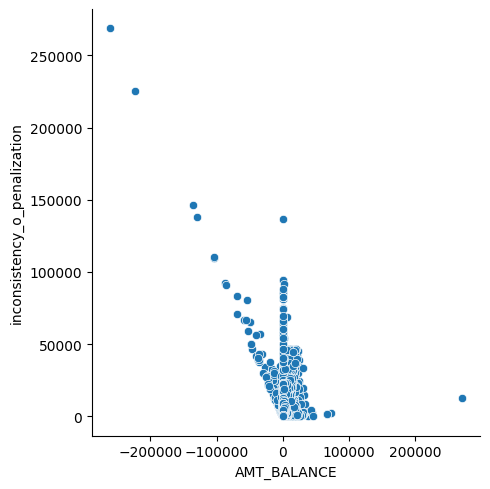

In [ ]:
#16
credit_card_df["inconsistency_o_penalization"] = (invariant_violated_cases["AMT_INST_MIN_REGULARITY"] - invariant_violated_cases["AMT_TOTAL_RECEIVABLE"]).clip(lower=0)
cases_of_analisis= credit_card_df[credit_card_df["inconsistency_o_penalization"] > 0]
sns.relplot(data= cases_of_analisis, x="AMT_BALANCE", y= "inconsistency_o_penalization", kind="scatter")
#This leads us to several interesting conclusions: first, it reinforces the premise that AMT_BALANCE  needs its lower limit clipped at 0 to avoid artifacts. 
#Negative balance (overpayment) can lead to errors when the metrics are calculated, such as in this case where a negative AMT_TOTAL_RECEIVABLE make AMT_INST_MIN_REGULARITY 
#bigger than the field that represent the rest of the debt 
#mixing them with the cases where more money is being demanded than the total of the remaining loan

In [ ]:
#17
mask_capital_bigger_than_total= (credit_card_df["AMT_RECEIVABLE_PRINCIPAL"] > credit_card_df["AMT_TOTAL_RECEIVABLE"])
print(mask_capital_bigger_than_total.sum())


excluding_overpayment= credit_card_df[(mask_capital_bigger_than_total) & (credit_card_df["AMT_TOTAL_RECEIVABLE"] > 0)]
print(len(excluding_overpayment))

pd.set_option('display.max_columns', None)
excluding_overpayment.head(20)


107986
572


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
3790198,1005714,455594,-62,9858.060,180000,0.0,0.0,0.0,0.0,10800.000,15300.0,15300.0,9200.745,8869.185,8869.185,0.0,0,0.0,0.0,35.0,Active,0,0
3137378,1005714,455594,-40,22458.195,180000,0.0,0.0,0.0,0.0,10800.000,13500.0,13500.0,21555.855,21469.320,21469.320,0.0,0,0.0,0.0,57.0,Active,0,0
3092778,1009822,293188,-41,1511.505,135000,0.0,0.0,0.0,0.0,6750.000,13950.0,13950.0,1308.825,841.545,841.545,0.0,0,0.0,0.0,54.0,Active,0,0
1253032,1031422,298614,-44,193.815,90000,0.0,0.0,0.0,0.0,3607.695,3690.0,3690.0,96.345,15.165,15.165,0.0,0,0.0,0.0,32.0,Active,0,0
94933,1031422,298614,-42,195.750,90000,0.0,0.0,0.0,0.0,68.535,0.0,0.0,58.815,17.100,17.100,0.0,0,0.0,0.0,34.0,Active,1,0
3060969,1031422,298614,-41,196.695,90000,0.0,0.0,0.0,0.0,67.500,0.0,0.0,58.815,18.045,18.045,0.0,0,0.0,0.0,35.0,Active,32,0
3083985,1031422,298614,-40,197.595,90000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,58.815,18.945,18.945,0.0,0,0.0,0.0,35.0,Active,62,0
188794,1031422,298614,-39,198.540,90000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,58.815,19.890,19.890,0.0,0,0.0,0.0,35.0,Active,93,0
651659,1031422,298614,-38,199.485,90000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,58.815,20.835,20.835,0.0,0,0.0,0.0,35.0,Active,124,0
1039136,1031422,298614,-37,200.385,90000,0.0,0.0,0.0,0.0,0.000,0.0,0.0,58.815,21.735,21.735,0.0,0,0.0,0.0,35.0,Active,154,0
